In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.methods import RVPermutationTest
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np
from functools import partial

In [2]:
colors = {
    'PermutationTest_cvm_stat_multivariate': '#1f77b4',
    'RVPermutationTest': '#9467bd',
    'DiffusionCorrelation':'#ff7f0e',
    'LLKRatioTest':'#2ca02c',
    'QAP':'#d62728',
    'PermutationTest_cvm_stat_block_independence':'#17BECF',
    'PermutationTest_latent':'#8C564B',
}

linestyles = {
    'PermutationTest_cvm_stat_multivariate': '-',
    'RVPermutationTest': (0, (8, 4)),
    'DiffusionCorrelation': (0, (5, 3)),
    'LLKRatioTest': (0, (2, 2)),
    'QAP': (0, (6, 3, 1.5, 3)),
    'PermutationTest_cvm_stat_block_independence': (0, (8, 3, 1.5, 3, 1.5, 3)),
    'PermutationTest': (0, (1, 2)),
}
plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [3]:
results1 = pd.read_csv("simulation_results_20260311_1610.csv")

results2 = pd.read_csv("simulation_results_20260312_0828.csv")

In [24]:
results3 = pd.read_csv("simulation_results_20260312_2242.csv")

In [25]:
results = pd.concat([results1, results2, results3], ignore_index=True)

In [26]:
import re

def parse_config_string(s):

    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # extract method class
    m = re.search(r"<class '([^']+)'>", s)
    method_class = m.group(1).split('.')[-1] if m else None

    # extract test function
    f = re.search(r"<function ([^ ]+)", s)
    test_function = f.group(1) if f else None

    # construct final method name
    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class

    pairs["method"] = method

    # remove original method field (the messy partial)
    pairs.pop("method", None)
    pairs["method"] = method

    return pairs

In [27]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [28]:
results['args'] = results['args'].apply(parse_config_string)

In [29]:
results['ComputeAll'] = results['ComputeAll'].apply(parse_result_string)

In [30]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results['n'] = results['args'].apply(lambda x: x.get("n", "NA"))
results['k'] = results['args'].apply(lambda x: x.get("k", "NA"))
results['method'] = results['args'].apply(lambda x: x.get("method", "NA").strip("'"))
results['solver'] = results['args'].apply(lambda x: x.get("solver", "NA").strip("'"))
results['copula_type'] = results['args'].apply(lambda x: x.get("copula_type", "NA").strip("'"))
results['dgp_name'] = results['args'].apply(lambda x: x.get("dgp_name", "NA").strip("'"))
results['marginals'] = results['args'].apply(lambda x: x.get("marginals", "NA").strip("'"))
results['rho'] = results['args'].apply(lambda x: x.get("rho", "NA").replace('np.float64(', '').replace(')', ''))

In [31]:
results['n'] = results['n'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))
results['k'] = results['k'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))

In [32]:
results["RelativeFrobeniusNorm_x"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results["RelativeFrobeniusNorm_z"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)
results["FalseRejection"] = results["ComputeAll"].apply(lambda x: x["FalseRejection"])
results["TrueRejection"] = results["ComputeAll"].apply(lambda x: x["TrueRejection"])
results["Rejection"] = results["ComputeAll"].apply(lambda x: x["Rejection"])

results['avg_rel_frob_x'] = (
    results
    .groupby(['n', 'method', 'marginals', 'copula_type'])['RelativeFrobeniusNorm_x']
    .transform('mean')
)

### Defining different aggregations

In [33]:
# based on dgp
results_gaussian = results[(results["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results[(results["dgp_name"] == "BernoulliNetwork")].copy()

In [34]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == "0.0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == "0.5")].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == "0.2")].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.0")].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.5")].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.2")].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [35]:
agg_null_gaussian = aggregate_results(results_null_gaussian,
                                      y_axis="FalseRejection",
                                      x_axis="n",
                                      factors=["marginals", "method", "copula_type"])

agg_null_bernoulli = aggregate_results(results_null_bernoulli, 
                             y_axis="FalseRejection",
                             x_axis="n",
                             factors=["marginals", "method", "copula_type"])

agg_null_gaussian_frob = aggregate_results(results_null_gaussian,
                                           y_axis="FalseRejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["marginals", "method", "copula_type"])
agg_null_bernoulli_frob = aggregate_results(results_null_bernoulli,
                                           y_axis="FalseRejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["marginals", "method", "copula_type"])

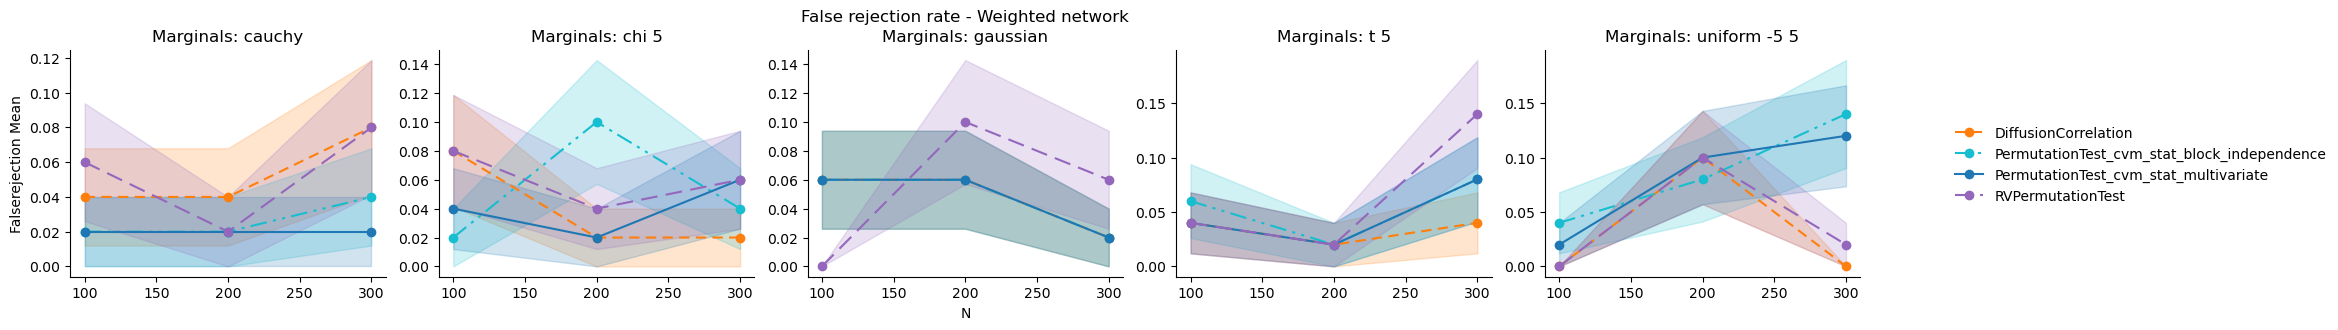

In [36]:
temp = agg_null_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="False rejection rate - Weighted network",
)

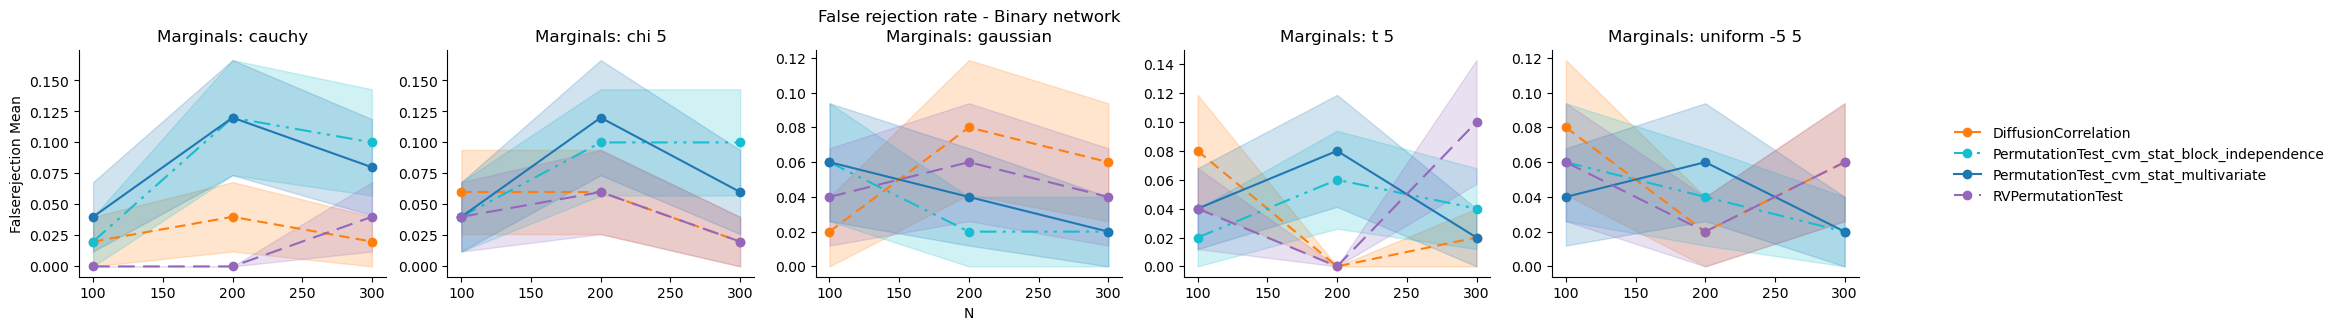

In [37]:
temp = agg_null_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="False rejection rate - Binary network",
)

flipping


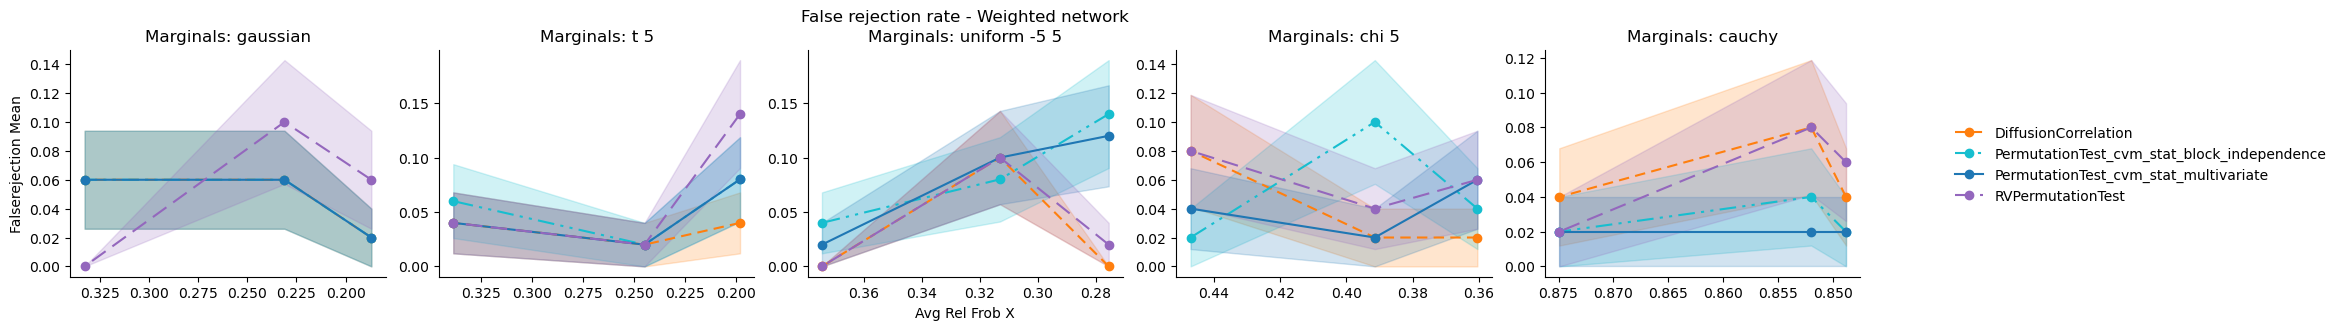

In [38]:
temp = agg_null_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

flipping


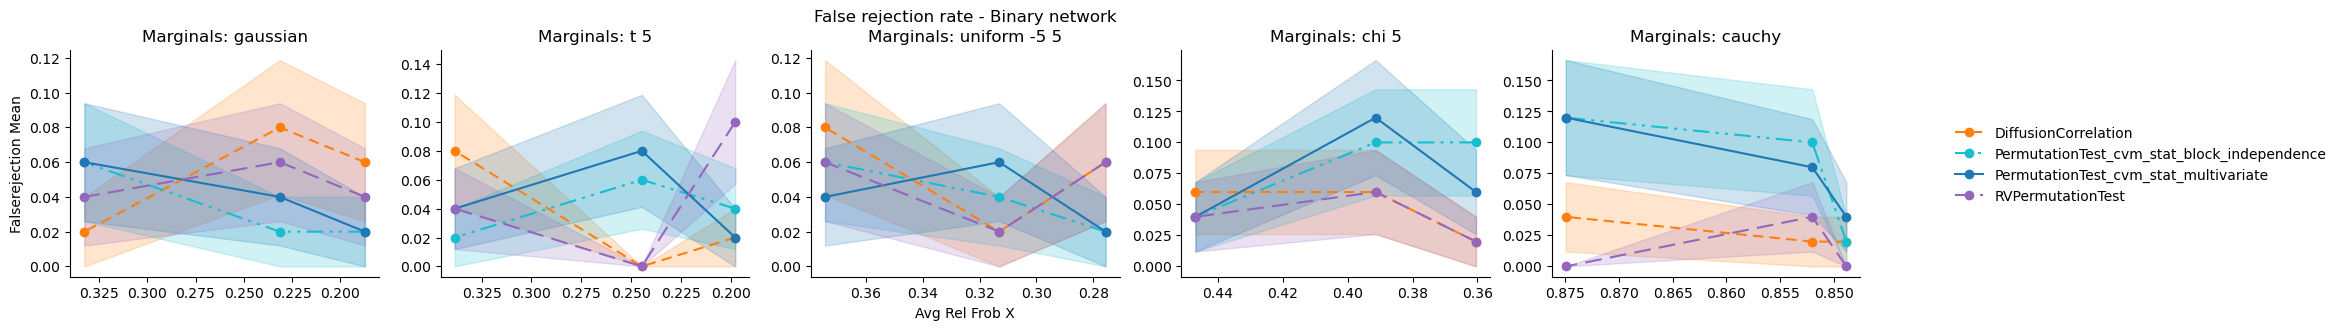

In [39]:
temp = agg_null_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Binary network",
    flip_x_axis=True,
)

### Power

In [40]:
agg_alt_02_gaussian = aggregate_results(
    results_alt_02_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "method", "copula_type"]
)
agg_alt_02_bernoulli = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["marginals", "method", "copula_type"]
)

agg_alt_02_gaussian_frob = aggregate_results(
    results_alt_02_gaussian,
    y_axis="TrueRejection",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula_type"]
)

agg_alt_02_bernoulli_frob = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="TrueRejection",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula_type"]
)

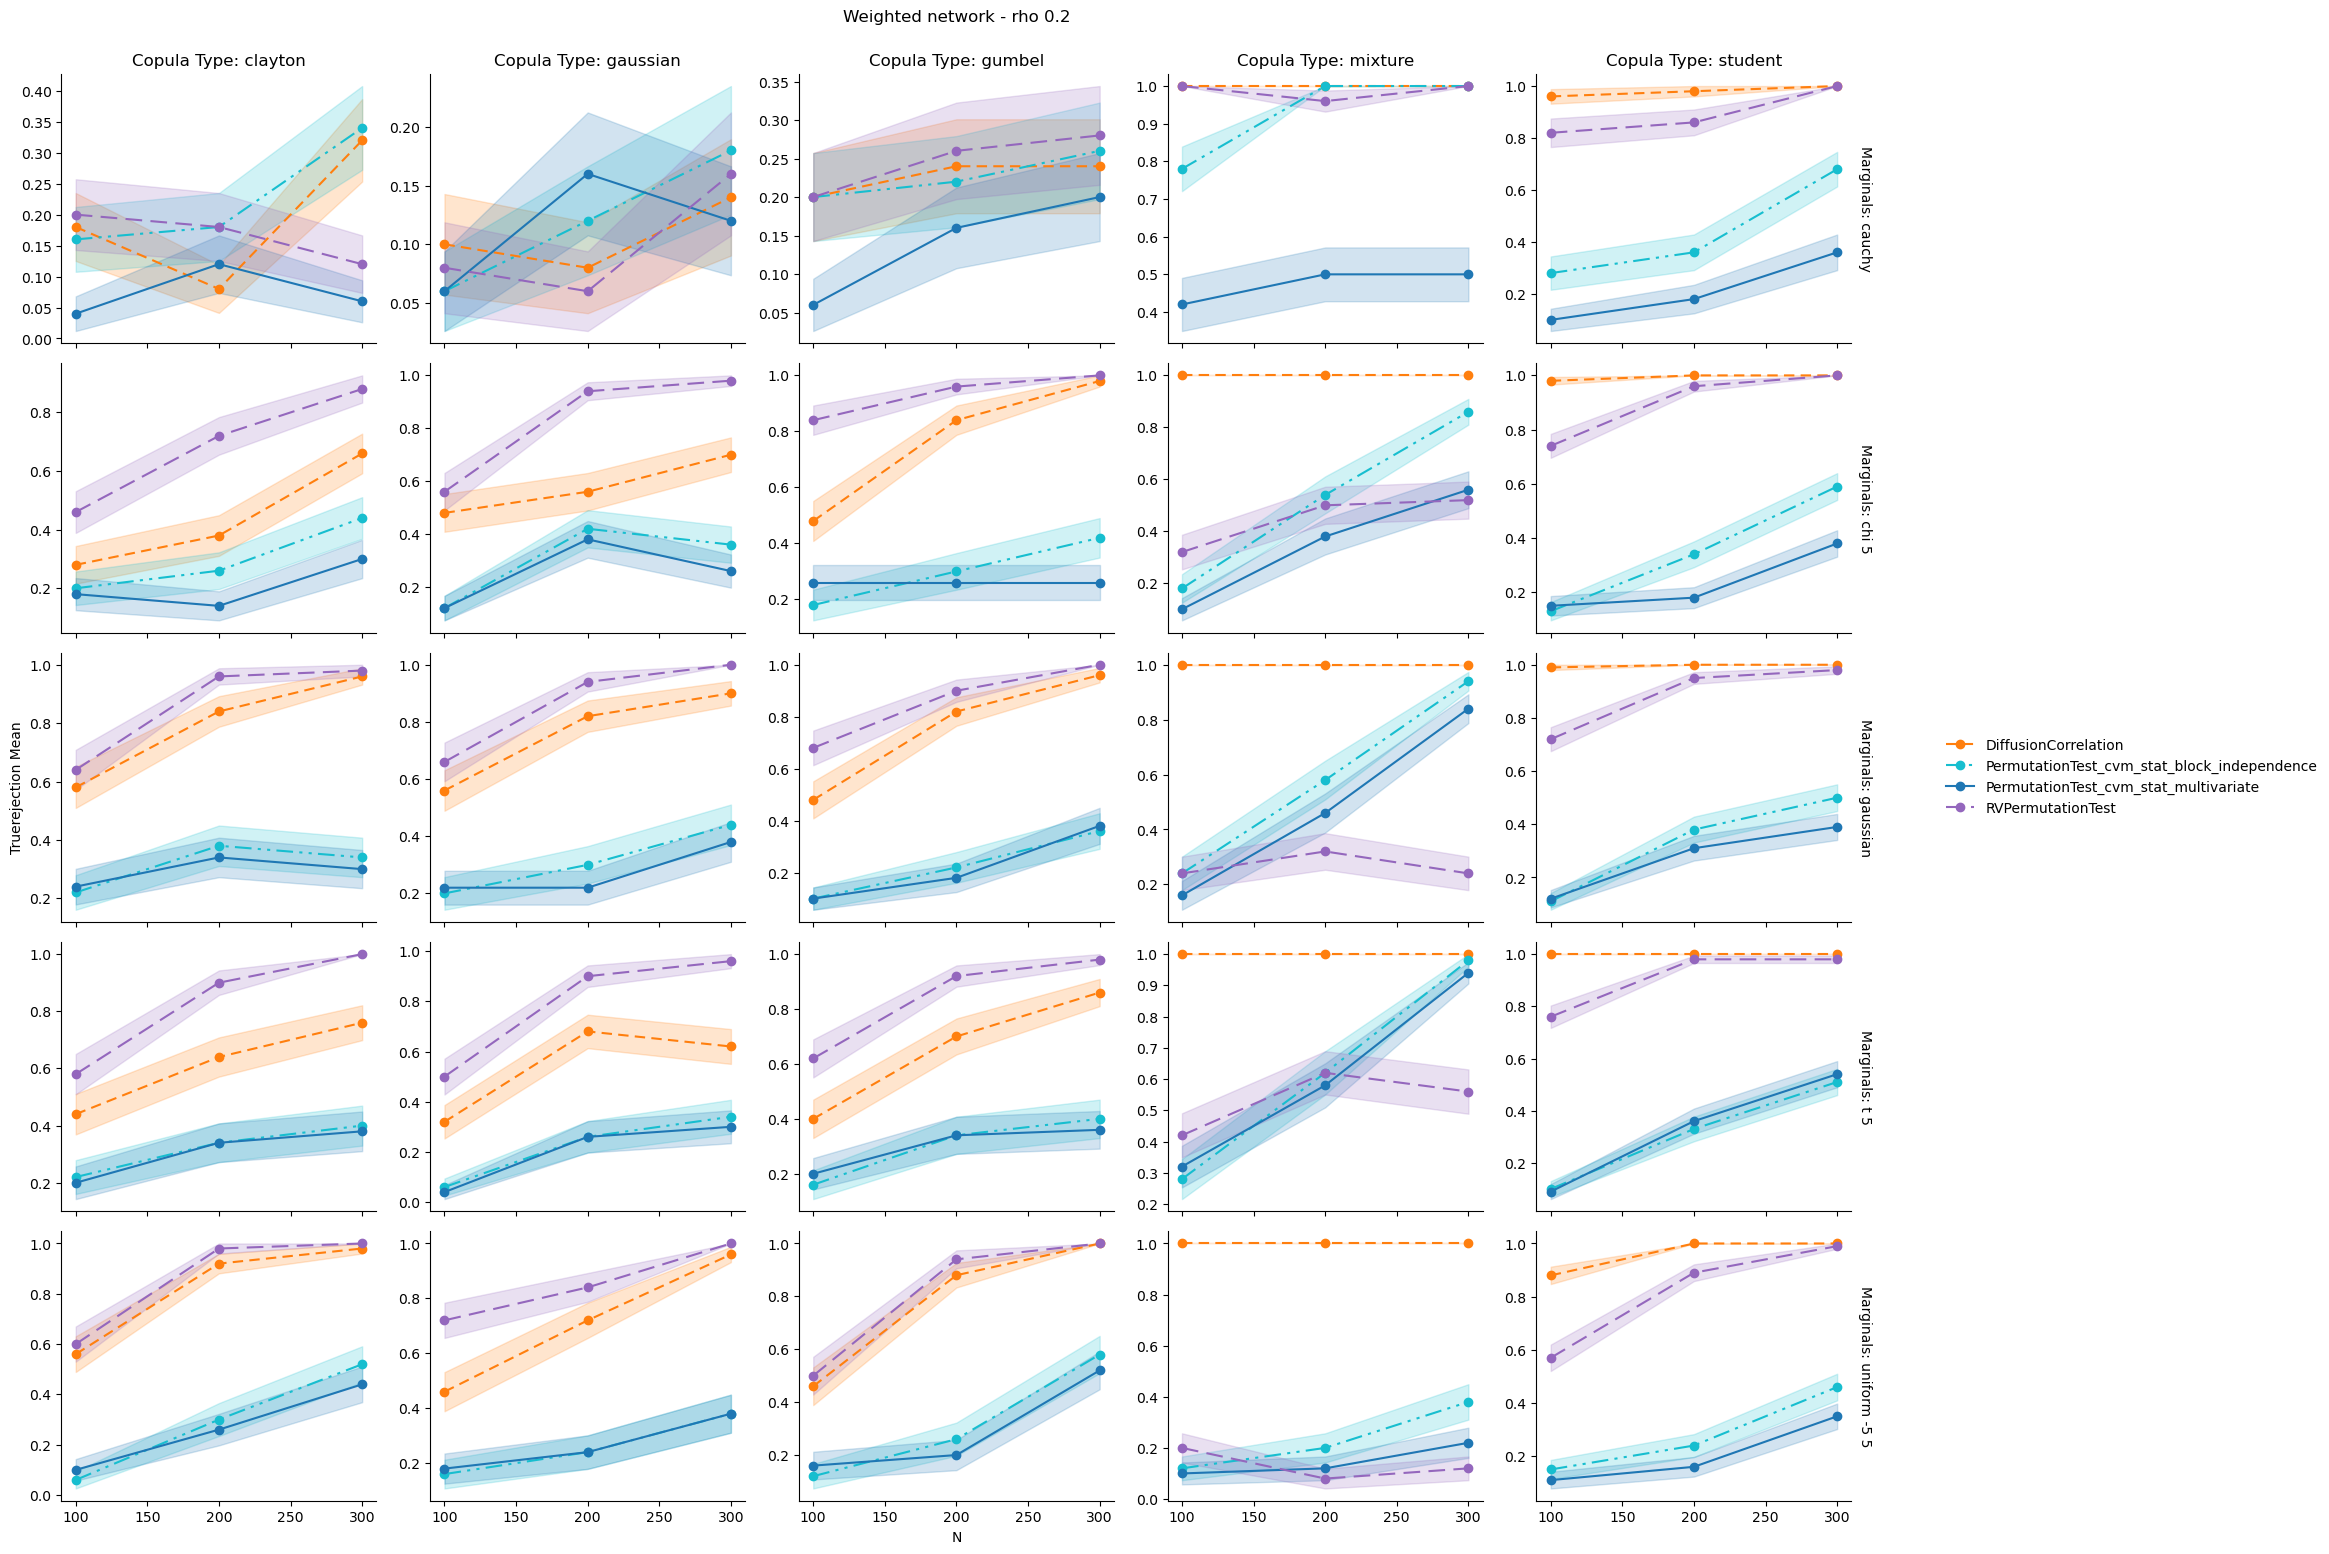

In [41]:
temp = agg_alt_02_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

flipping


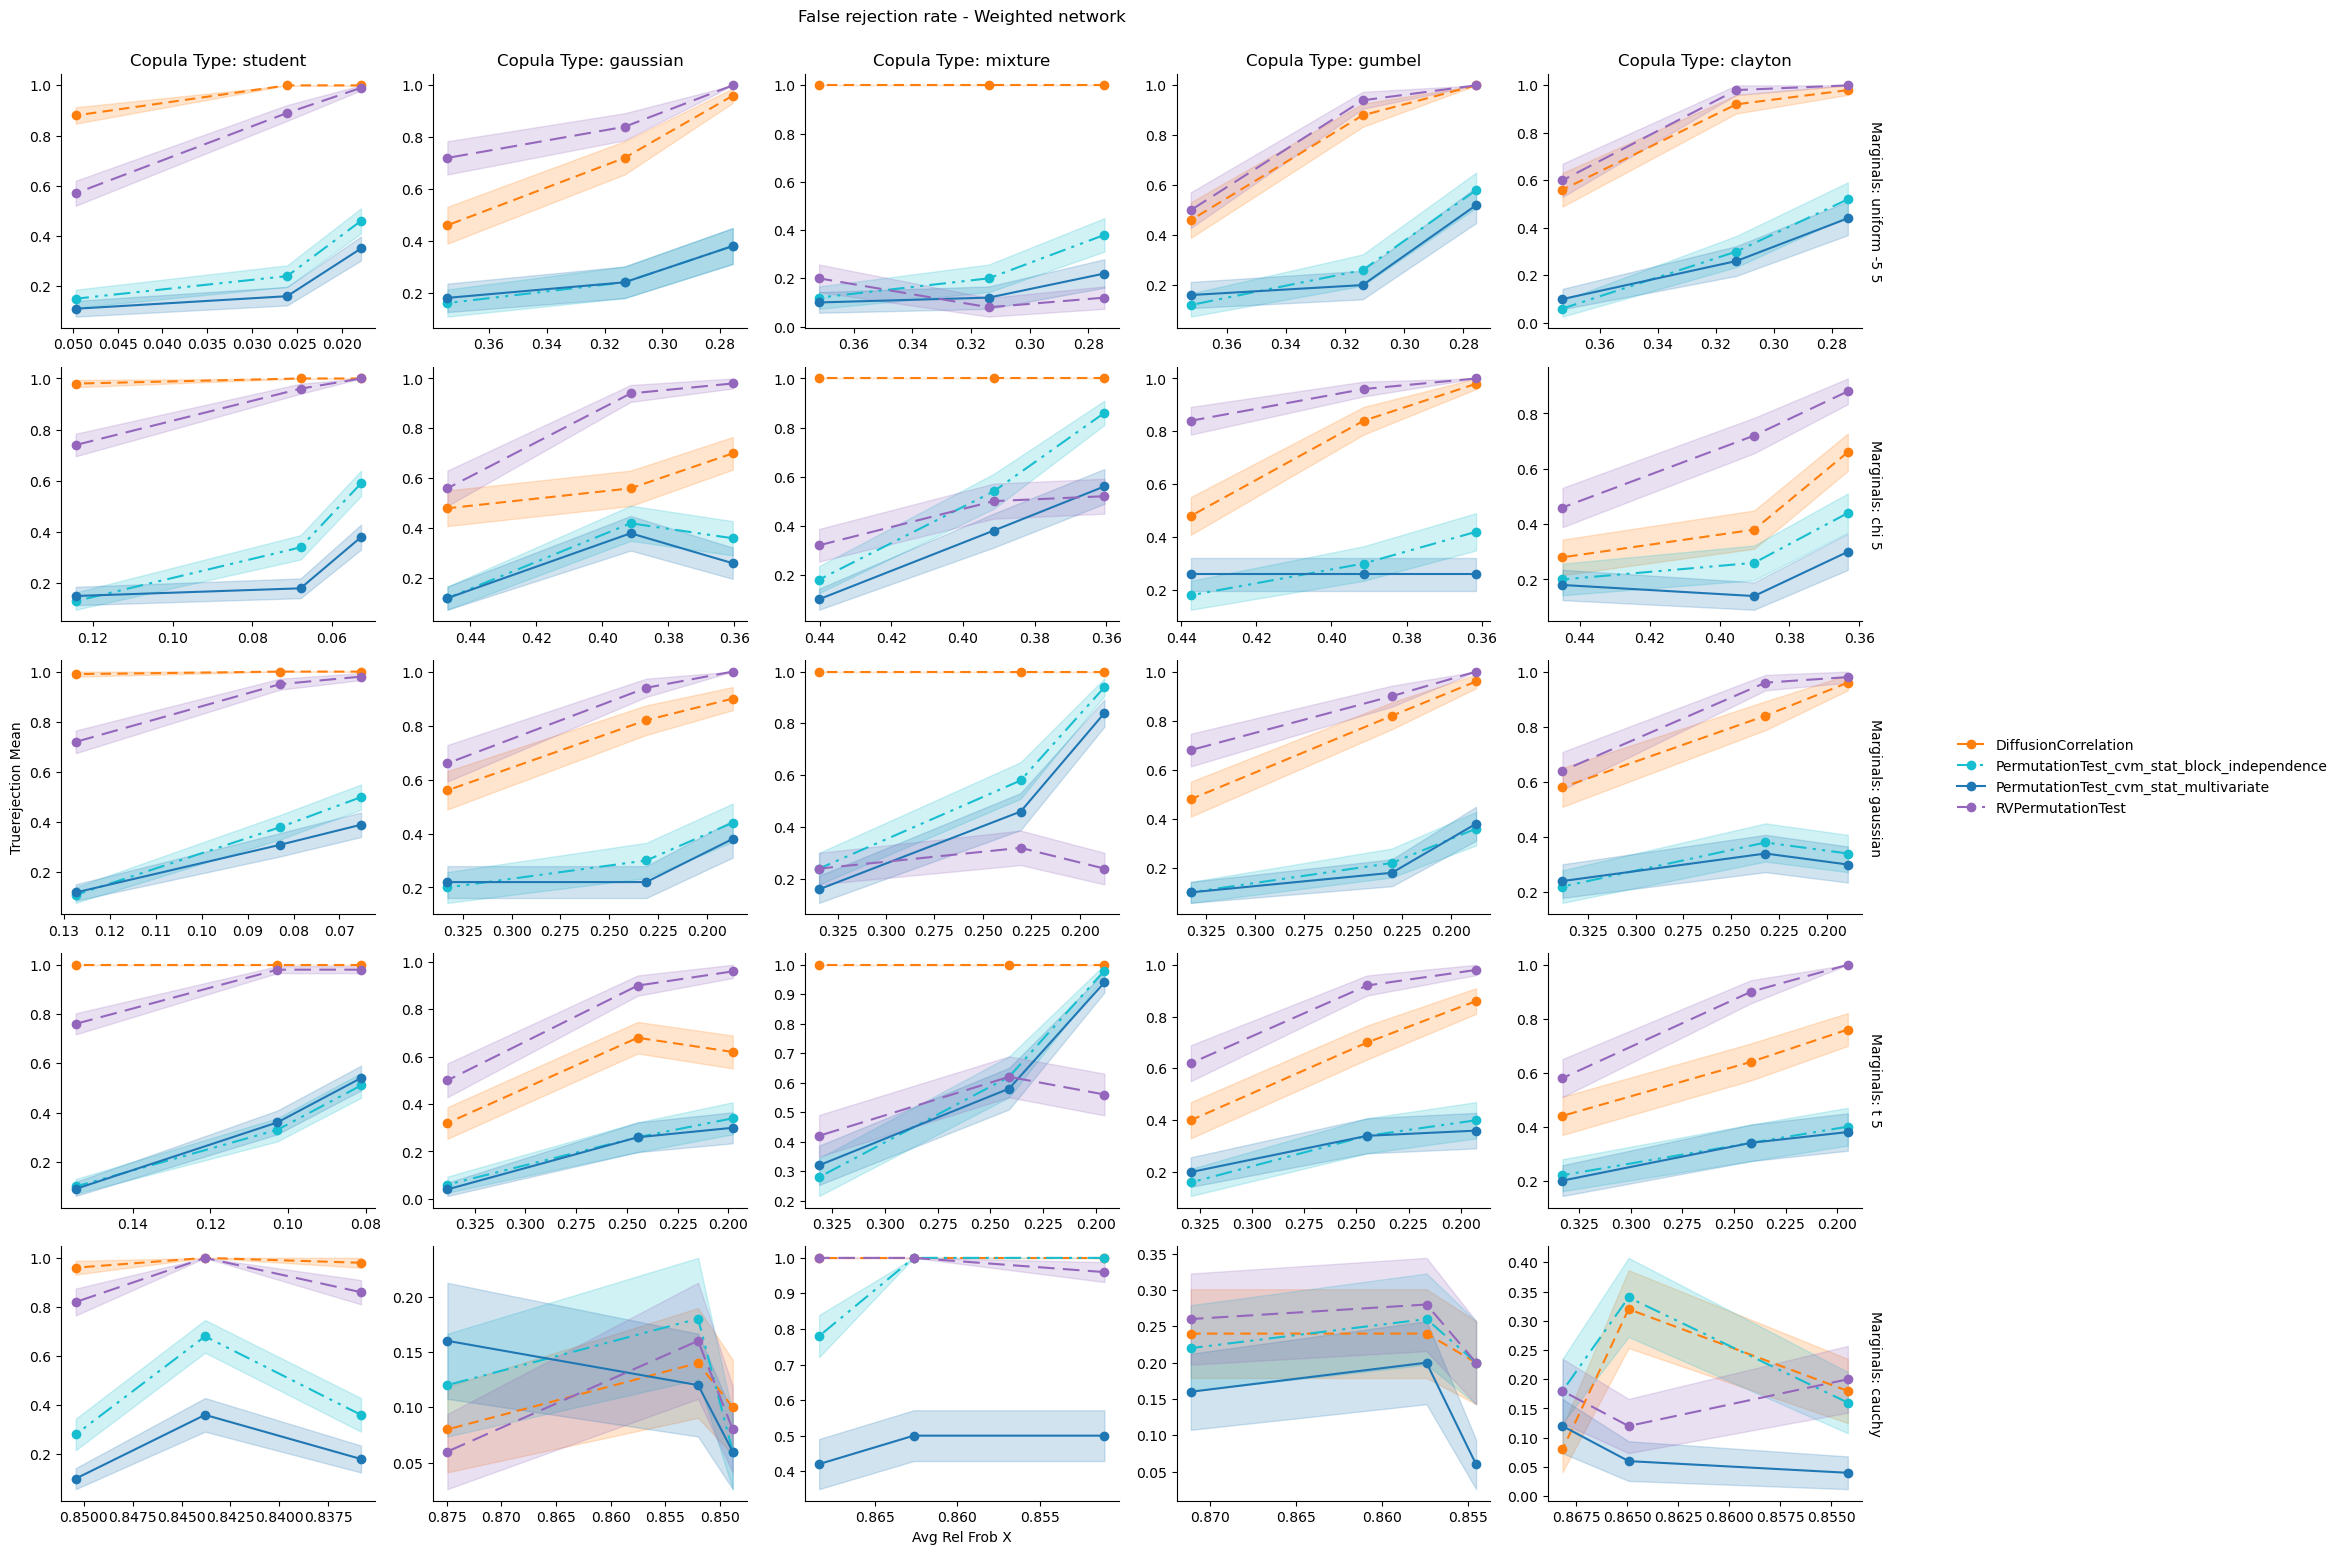

In [42]:
temp = agg_alt_02_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type","marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

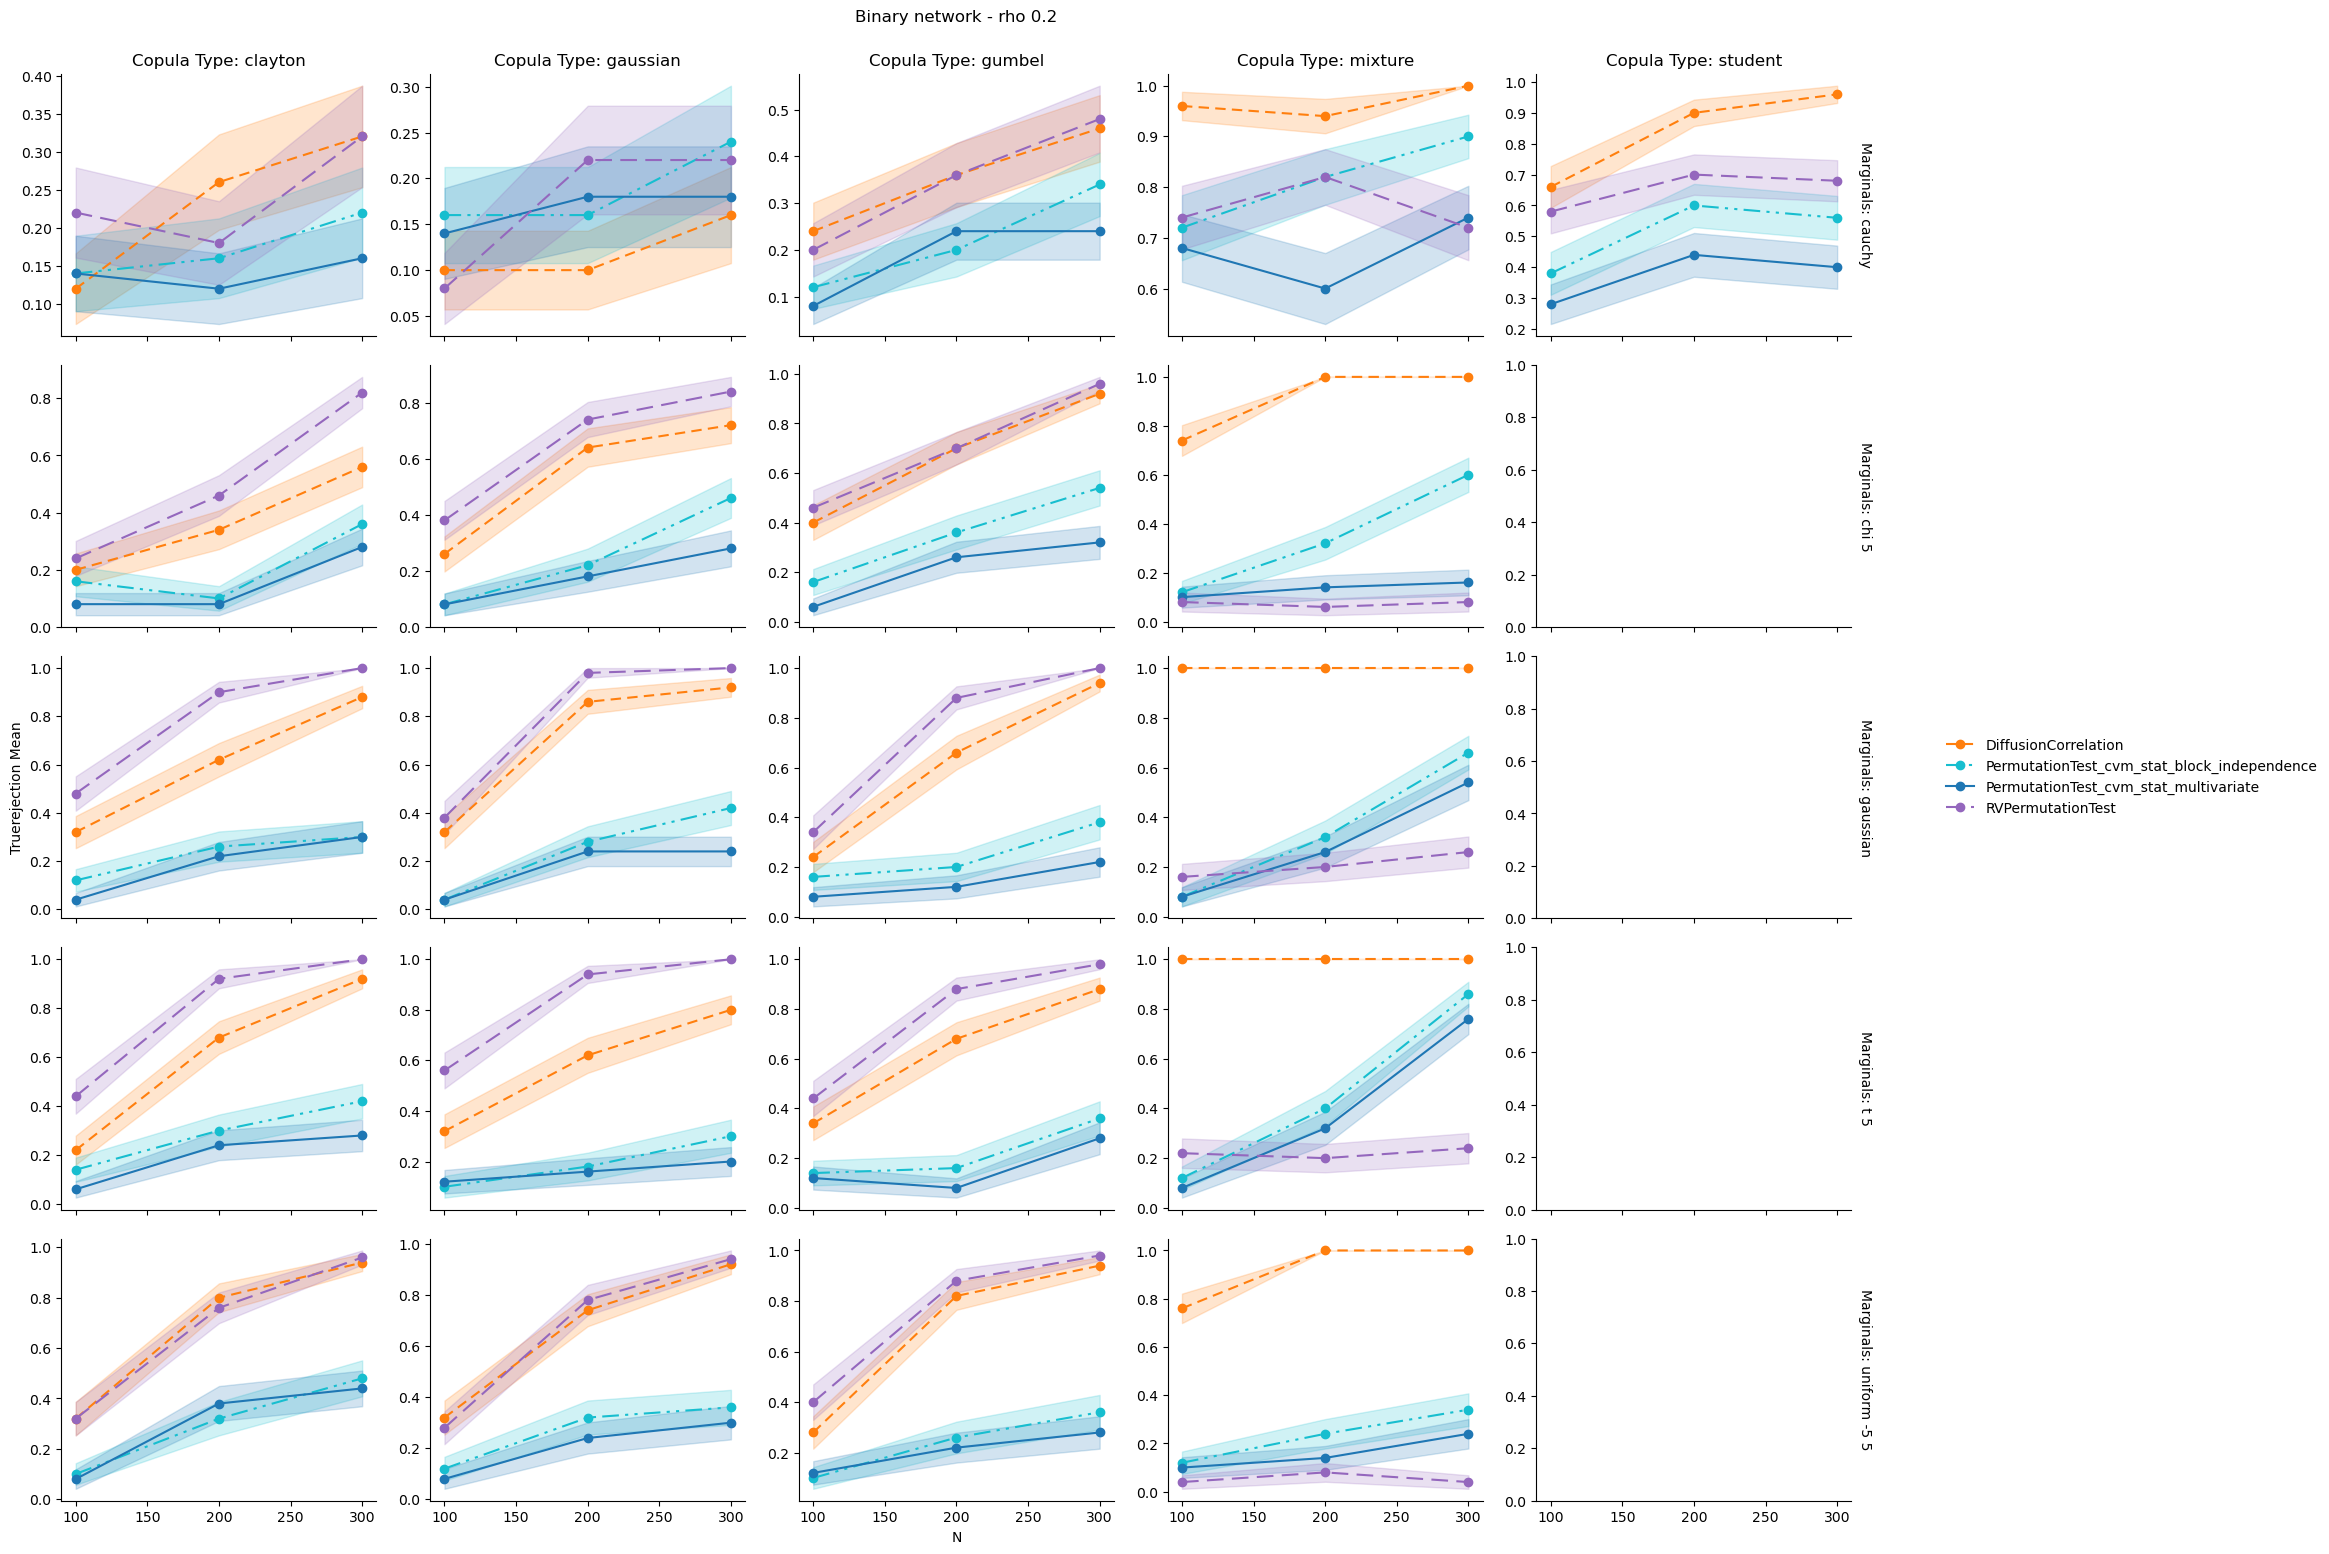

In [43]:
temp = agg_alt_02_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
)